# Matching Anomalies to Astronomical Intuition

In [1]:
import os

# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

from anomaly.plot import add_line_indicators
from anomaly.plot import spec_photo_thumbnail
from anomaly.utils import specobjid_to_idx

# from anomaly.utils import get_sdss_spec_img


from astroExplain.spectra import clustering
from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Lime weights

In [3]:
def load_xai(n_segments: int, run_ids: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [4]:
def load_xai_latent(run_ids_dict: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_array = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")

    weights_dict = {}

    for n_segments in run_ids_dict.keys():

        run_id = run_ids_dict[n_segments]

        weights_dict[n_segments] = np.load(
            f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r"
        )
    return anomalies_arr, specobjids_array, weights_dict

In [5]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Residuals

In [7]:
def squared_residual(spec, spec_rec):

    flux_diff = np.abs(spec - spec_rec)

    return flux_diff**2

## Plot 5X2 explanations

In [20]:
def plot_same_anomaly_explanations(
    data: dict,
    wave_nm: np.ndarray,
    line_configs: dict,
    spec_ylim,
    spec_yticks,
    xai_config: dict = {"y_lim": (0, 1.35), "y_ticks": [0, 0.5, 1]},
    text_dict={"x": 0.01, "y": 0.9, "ha": "left", "va": "center"},
    bbox_to_anchor=(0.695, 0.52, 0.5, 0.5),
    figsize=(14, 8.75),
    lw_dict: dict = {"spec": 0.75, "xai": 0.75},
):

    spectrum = data["spectrum"]
    image = img_common_dict[anomaly_name]

    fig, axs = plt.subplots(5, 2, sharex=True, figsize=figsize)

    # Map the scores to their respective rows and columns
    scores_layout = [
        ("SE", "RSE"),  # Row 1
        ("Filter SE", "Filter RSE"),  # Row 2
        ("Trim SE", "Trim RSE"),  # Row 3
        ("Filter + Trim SE", "Filter + Trim RSE"),  # Row 4
    ]

    # =================================================================================
    # Plot Row 0: Original Spectrum (Both Columns)
    # =================================================================================
    for c in [0, 1]:

        axs[0, c], _ = spec_photo_thumbnail(
            axs[0, c],
            wave_nm,
            spectrum,
            image,
            add_image=True,
            bbox_to_anchor=bbox_to_anchor,
            lw=lw_dict["spec"],
        )
        axs[0, c].set_ylim(spec_ylim)
        axs[0, c].set_yticks(spec_yticks)
        axs[0, c].minorticks_on()

        if c == 0:
            axs[0, c].set_ylabel("Flux")
        else:
            axs[0, c].tick_params(labelleft=False)

        if line_configs.get("spectrum", {}).get("active_lines"):
            add_line_indicators(
                axs[0, c], wave_nm, spectrum, **line_configs["spectrum"]
            )

    # ================================================================================
    # Rows 1-4: Explanations
    # ================================================================================
    for i, (score_se, score_rse) in enumerate(scores_layout):
        # Offset by 1 because Row 0 is the spectrum
        r = i + 1
        # Iterate through Col 0 (SE) and Col 1 (RSE)
        for c, score_name in enumerate([score_se, score_rse]):

            axs[r, c], _ = spec_photo_thumbnail(
                axs[r, c], wave_nm, data[score_name], add_image=False, lw=lw_dict["xai"]
            )
            axs[r, c].set_ylim(xai_config["y_lim"])
            axs[r, c].set_yticks(xai_config["y_ticks"])
            axs[r, c].minorticks_on()
            axs[r, c].text(
                text_dict["x"],
                text_dict["y"],
                score_name,
                ha=text_dict["ha"],
                va=text_dict["va"],
                transform=axs[r, c].transAxes,
            )

            if c == 0:
                axs[r, c].set_ylabel("Weights")
            else:
                axs[r, c].tick_params(labelleft=False)

            # Fetch the specific config for this score_name
            # If it doesn't exist in the dictionary, returns an empty dict {}
            current_config = line_configs.get(score_name, {})

            if current_config.get("active_lines"):
                add_line_indicators(
                    axs[r, c], wave_nm, data[score_name], **current_config
                )

    # ================================================================================
    # Global Axes Settings
    # ================================================================================
    wave_ticks = list(np.arange(400, 751, 50))
    for col in [0, 1]:
        axs[4, col].set_xlim(350, 770)
        axs[4, col].set_xticks(wave_ticks)
        axs[4, col].set_xlabel(r"$\lambda$ [nm]")
    return fig, axs

# Config

## Constants

In [9]:
score_name_map = {
    "mse": "SE",
    "mse_filter_250": "Filter SE",
    "mse_97": "Trim SE",
    "mse_filter_250_97": "Filter + Trim SE",
    "mse_rel": "RSE",
    "mse_filter_250_rel": "Filter RSE",
    "mse_97_rel": "Trim RSE",
    "mse_filter_250_97_rel": "Filter + Trim RSE",
}

## Directories

In [10]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
explanations_dir = f"{data_dir}/explanations"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"

# Data

In [11]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")
bin_id = "bin_03"
latent_arr = np.load(f"{latent_dir}/{bin_id}/latent_{bin_id}.npy", mmap_mode="r")

## VAE Models

In [12]:
bin_id = "bin_03"
# Load VAE
ae_model_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)

# Residual based

## Explanations

In [13]:
bin_id = "bin_03"
n_segments = 221

anomalies_se_all_dict = {}
specids_se_all_dict = {}
weights_se_all_dict = {}

run_ids_221_dict = {
    "mse": "xai_202607061319_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250": "xai_202607061811_uniform_221_samples_50000_scale_0.9",
    "mse_97": "xai_202607061937_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_97": "xai_202607062045_uniform_221_samples_50000_scale_0.9",
    # ----
    "mse_rel": "xai_202607062150_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_rel": "xai_202607070126_uniform_221_samples_50000_scale_0.9",
    "mse_97_rel": "xai_202607062313_uniform_221_samples_50000_scale_0.9",
    "mse_filter_250_97_rel": "xai_202607071050_uniform_221_samples_50000_scale_0.9",
}


for score_name, run_id in run_ids_221_dict.items():

    load_from = f"{explanations_dir}/{bin_id}/{score_name}"

    (
        anomalies_arr,
        specobjids_arr,
        weights_dict,
    ) = load_xai(n_segments=n_segments, run_ids=run_id, load_from=load_from)

    anomalies_se_all_dict[score_name] = anomalies_arr
    specids_se_all_dict[score_name] = specobjids_arr
    weights_se_all_dict[score_name] = weights_prep(
        weights=weights_dict, n_segments=n_segments
    )

## Data prep

In [18]:
bin_id = "bin_03"

common_dict = {
    # row 1
    "narrow_line": 734111514142730240,
    "broad_line_large_OIII": 1633733043925575680,
    # row 2
    "broad_emission_dips_OIII_half": 1192355533059811328,
    "star_forming_step_blue_slope": 1959124163192973312,
    # row 3
    "blue_bump_emission": 531492683672217600,
    "passive_star": 1780176998165932032,
    # row 4
    "spike": 1413149843194406912,
    "noise_forest": 637325355518027776,
}

spec_common_dict = {}
# dict with all explanations: xai_common_dict[anomaly_name][score_name] = weights
xai_common_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/res_common_xai"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for anomaly_name, specobjid in common_dict.items():

    print(f"Processing anomaly: {anomaly_name}")
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)

    xai_common_dict[anomaly_name] = {}
    xai_common_dict[anomaly_name]["spectrum"] = spectra[idx_spectrum]

    for metric, score_name in score_name_map.items():

        idx_mask = specids_se_all_dict[metric] == specobjid

        _weights = weights_se_all_dict[metric]["weights"][idx_mask][0]
        _weights = np.abs(_weights) / np.nanmax(np.abs(_weights))
        xai_common_dict[anomaly_name][score_name] = _weights

    # # download image and spectrum
    # ra, dec = final_meta_df[['ra', 'dec']].loc[specobjid].values
    # get_sdss_spec_img(
    #     specobjid=specobjid, ra=ra, dec=dec, save_to=save_to
    # )

# Load photometry
img_common_dict = {}

for key in common_dict.keys():

    objid = common_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_common_dict[key] = img_

Get specs and load photometry
Processing anomaly: narrow_line
Processing anomaly: broad_line_large_OIII
Processing anomaly: broad_emission_dips_OIII_half
Processing anomaly: star_forming_step_blue_slope
Processing anomaly: blue_bump_emission
Processing anomaly: passive_star
Processing anomaly: spike
Processing anomaly: noise_forest


# noise_forest

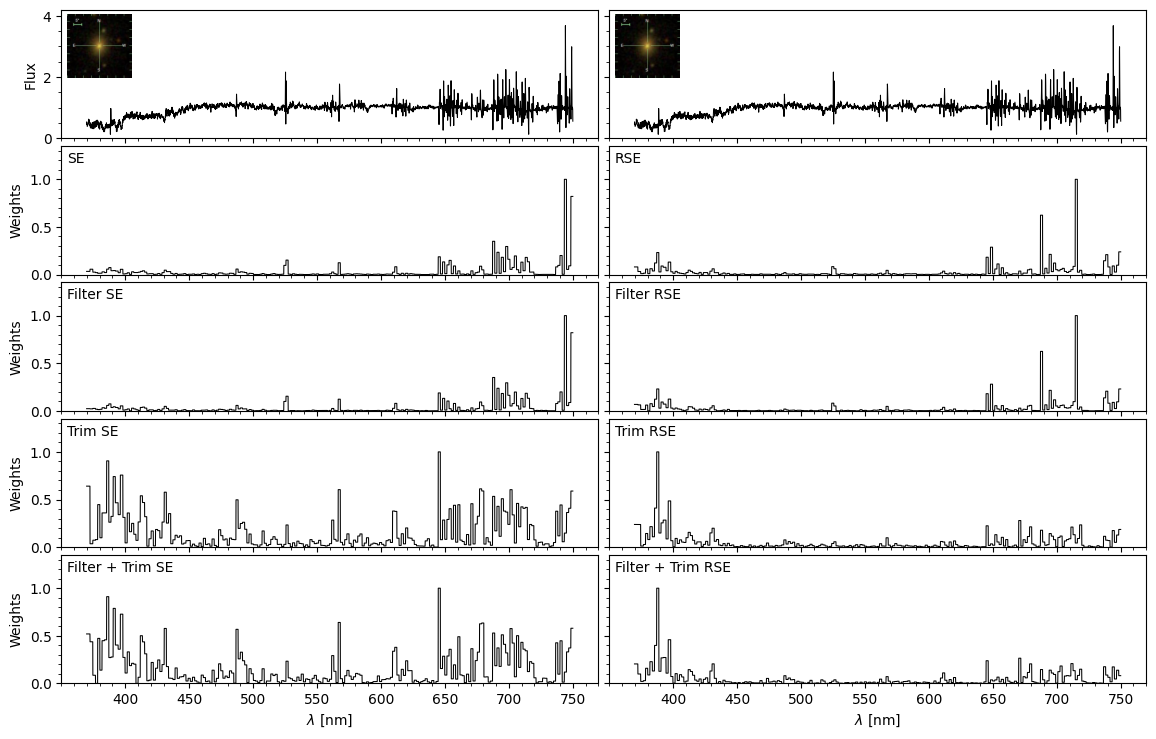

In [ ]:
anomaly_name = "noise_forest"

data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

spec_ylim = (0, 4.2)
spec_yticks = range(0, 5, 2)

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.4,
        "indicator_height": 0.4,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": []},
    "RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    bbox_to_anchor=(-0.167, 0.52, 0.5, 0.5),
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)
# Save figure
fig.savefig(f"{ch_5_dir}/common_noise_forest_xai.pdf", bbox_inches="tight")

# broad_emission_dips_OIII_half

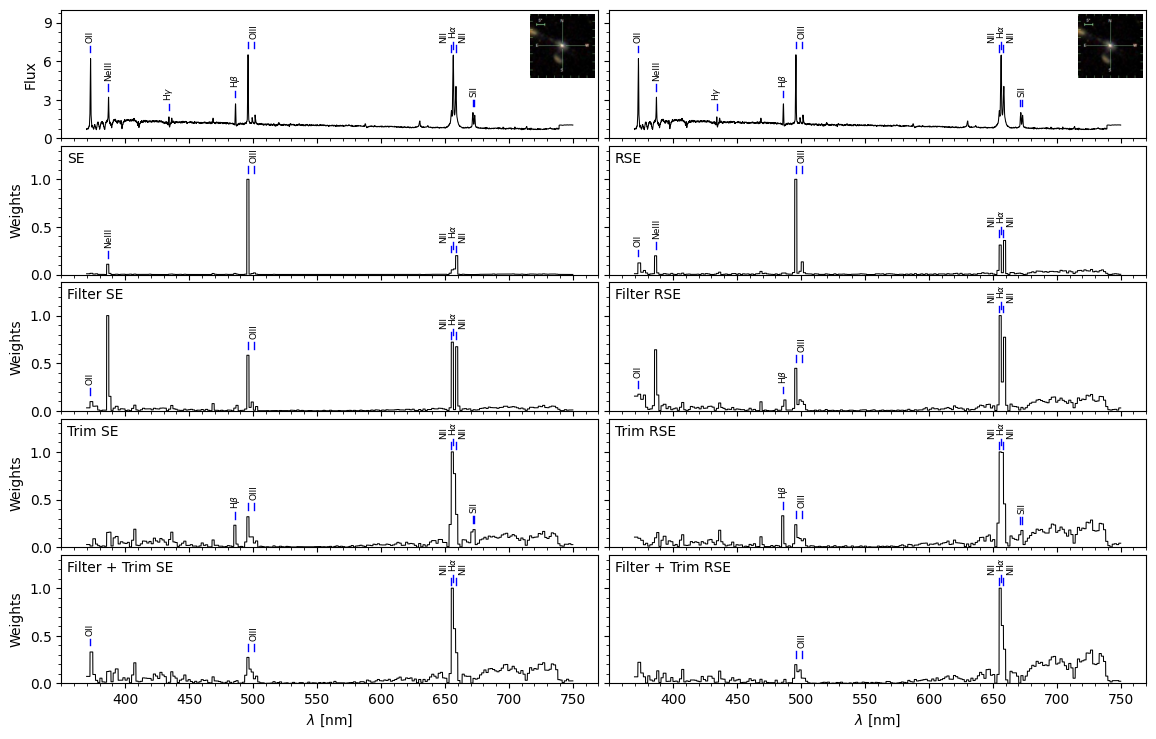

In [ ]:
anomaly_name = "broad_emission_dips_OIII_half"
spec_ylim = (0, 10)
spec_yticks = range(0, 10, 3)
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

# Configuration for explanations
base_exp_config = {
    # "indicator_starts": 0.15,
    # "indicator_height": 0.15,
    "indicator_starts": 0.07,
    "indicator_height": 0.07,
    "delta": 5,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.5,
        "indicator_height": 0.5,
        "delta": 5,
        "fontsize": 6.5,
        "active_lines": [
            "OII",
            "NeIII",
            "H_gamma",
            "H_beta",
            "OIII",
            "H_alpha",
            "SII",
        ],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["NeIII", "OIII", "H_alpha"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["OII", "OIII", "H_alpha"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "OIII", "H_alpha"],
    },
    "RSE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_beta", "OIII", "H_alpha"],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)
plt.subplots_adjust(hspace=0.06, wspace=0.02)
# Save figure
fig.savefig(
    f"{ch_5_dir}/common_broad_emission_dips_OIII_half_xai.pdf", bbox_inches="tight"
)

# Narrow line

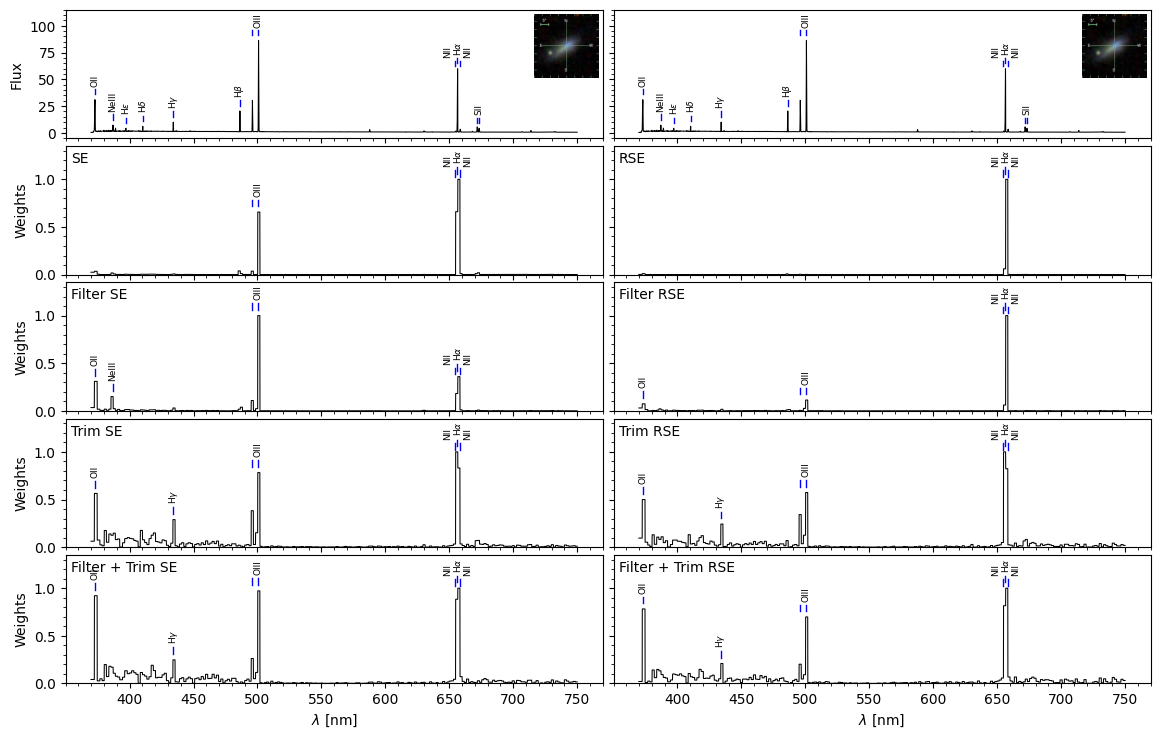

In [ ]:
anomaly_name = "narrow_line"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
spec_ylim = (-5, 115)
spec_yticks = range(0, 101, 25)
lw_dict: dict = {"spec": 0.75, "xai": 0.75}
# Base configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}
# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 5,
        "indicator_height": 5,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [
            "OII",
            "NeIII",
            "H_epsilon",
            "H_delta",
            "H_gamma",
            "H_beta",
            "OIII",
            "H_alpha",
            "SII",
        ],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "OIII", "H_alpha"],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "OIII", "H_alpha"],
    },
    "RSE": {**base_exp_config, "active_lines": ["H_alpha"]},
    "Filter RSE": {**base_exp_config, "active_lines": ["OII", "OIII", "H_alpha"]},
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "OIII", "H_alpha"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "OIII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    lw_dict=lw_dict,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)
# fig.savefig(f"{ch_5_dir}/common_narrow_line_xai.pdf", bbox_inches="tight")

# broad_line_large_OIII

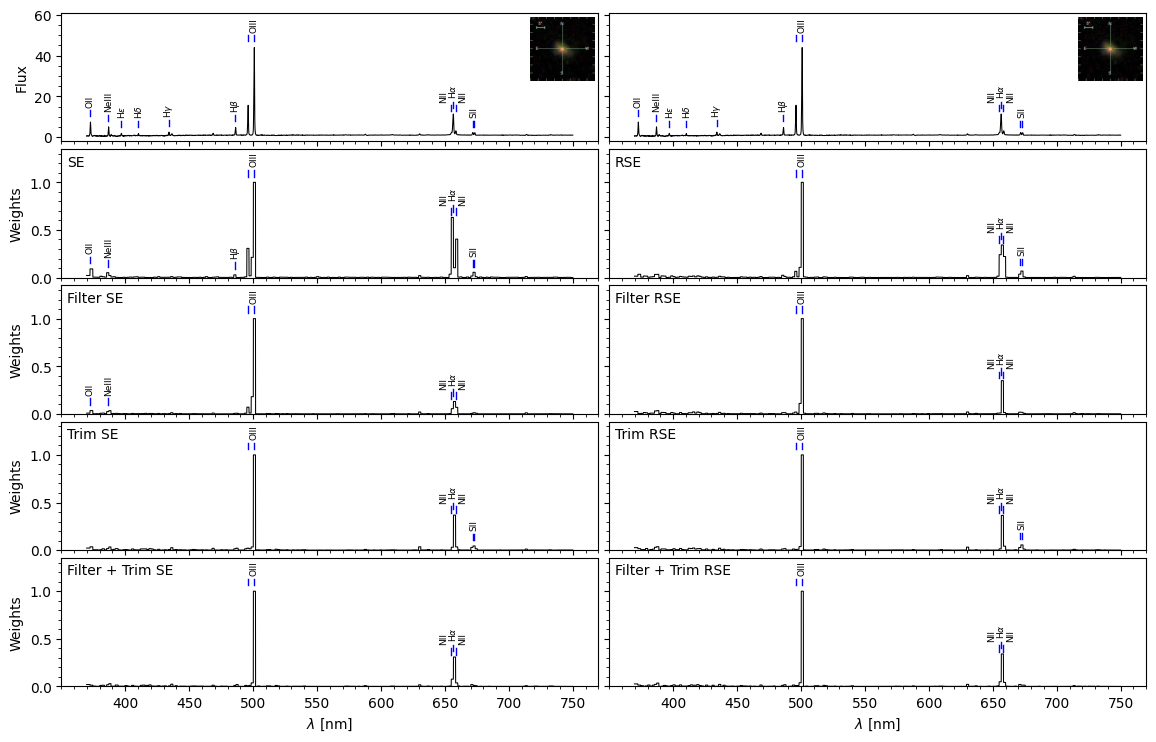

In [23]:
anomaly_name = "broad_line_large_OIII"
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

spec_ylim = (-2, 61)
spec_yticks = range(0, 61, 20)

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 3,
        "indicator_height": 3,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [
            "OII",
            "NeIII",
            "H_epsilon",
            "H_delta",
            "H_gamma",
            "H_beta",
            "OIII",
            "H_alpha",
            "SII",
        ],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha", "SII"],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": ["OIII", "H_alpha"]},
    "RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha", "SII"],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha"],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha", "SII"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["OIII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# star_forming_step_blue_slope

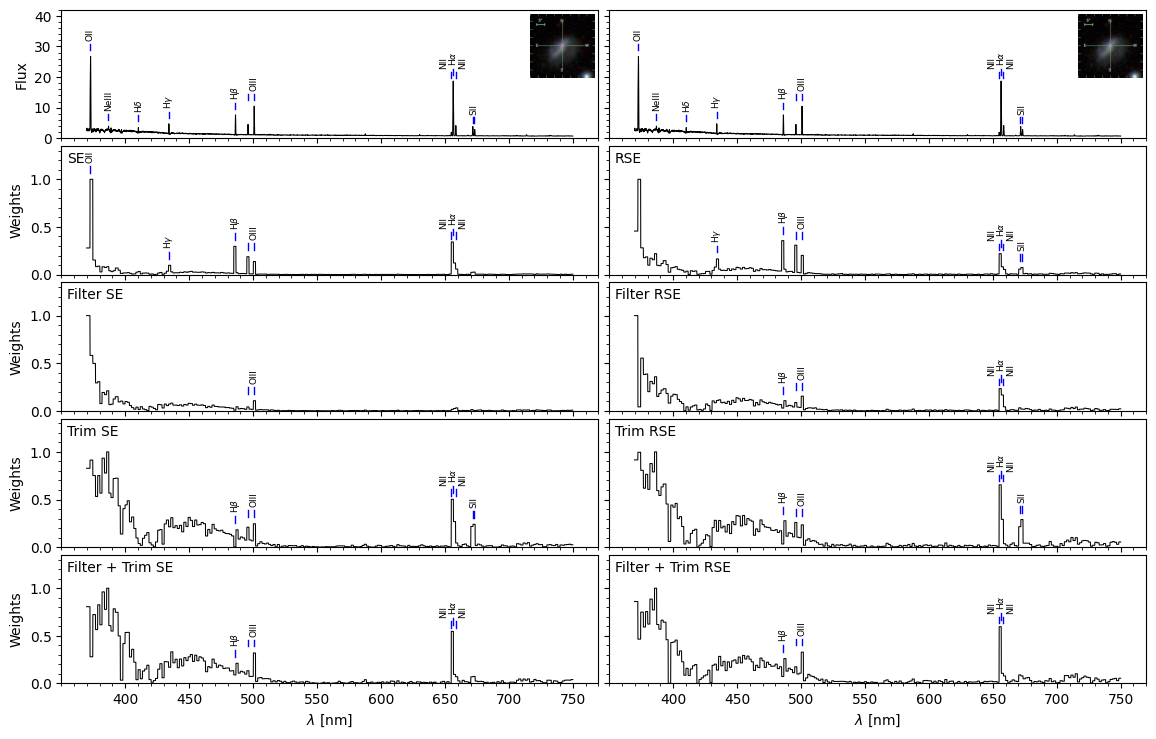

In [25]:
anomaly_name = "star_forming_step_blue_slope"
spec_ylim = (0, 42)
spec_yticks = range(0, 41, 10)
data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.07,
    "indicator_height": 0.07,
    "delta": 5,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 2,
        "indicator_height": 2,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [
            "OII",
            "NeIII",
            "H_delta",
            "H_gamma",
            "H_beta",
            "OIII",
            "H_alpha",
            "SII",
        ],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["OII", "H_gamma", "H_beta", "OIII", "H_alpha"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["OIII"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter + Trim SE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha"],
    },
    "RSE": {
        **base_exp_config,
        "active_lines": ["H_gamma", "H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha"],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha", "SII"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["H_beta", "OIII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)
# save figure
fig.savefig(
    f"{ch_5_dir}/common_star_forming_step_blue_slope_xai.pdf", bbox_inches="tight"
)

# blue_bump_emission

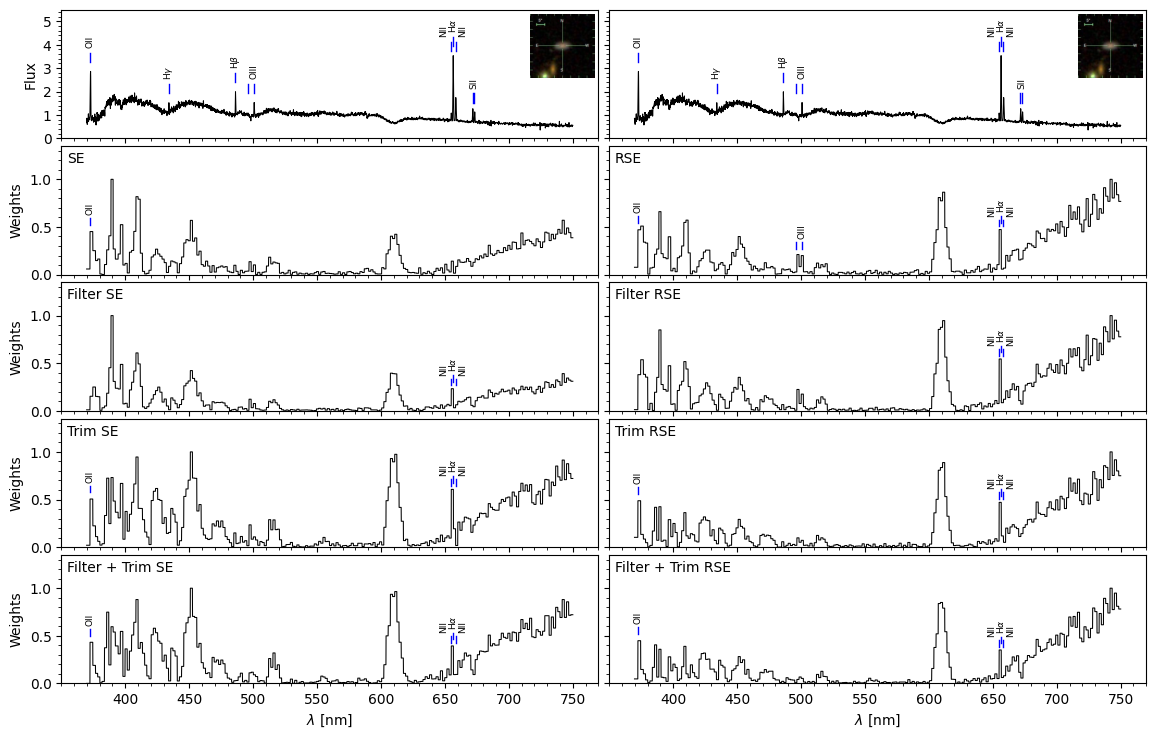

In [26]:
anomaly_name = "blue_bump_emission"

spec_ylim = (0, 5.5)
spec_yticks = range(0, 6, 1)

data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]
# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.07,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.4,
        "indicator_height": 0.4,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": ["OII", "H_gamma", "H_beta", "OIII", "H_alpha", "SII"],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": ["OII"],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": ["H_alpha"],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": ["OII", "H_alpha"],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": ["OII", "H_alpha"]},
    "RSE": {
        **base_exp_config,
        "active_lines": ["OII", "OIII", "H_alpha"],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": ["H_alpha"],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_alpha"],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": ["OII", "H_alpha"],
    },
}

fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)
# Save figure
# fig.savefig(f"{ch_5_dir}/common_blue_bump_emission_xai.pdf", bbox_inches="tight")

# passive_star

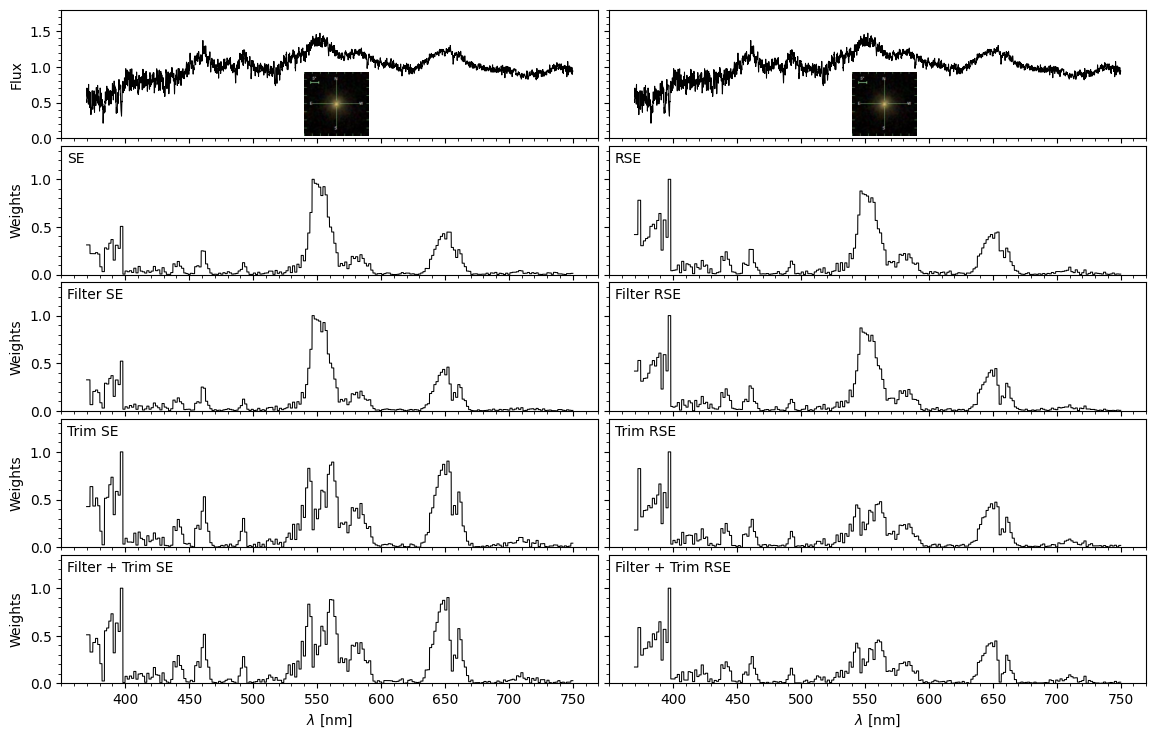

In [27]:
anomaly_name = "passive_star"
spec_ylim = (0, 1.8)
spec_yticks = [0, 0.5, 1, 1.5]

data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.07,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.4,
        "indicator_height": 0.4,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": []},
    "RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
}
fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
    bbox_to_anchor=(0.275, 0.07, 0.5, 0.5),
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)

# spike

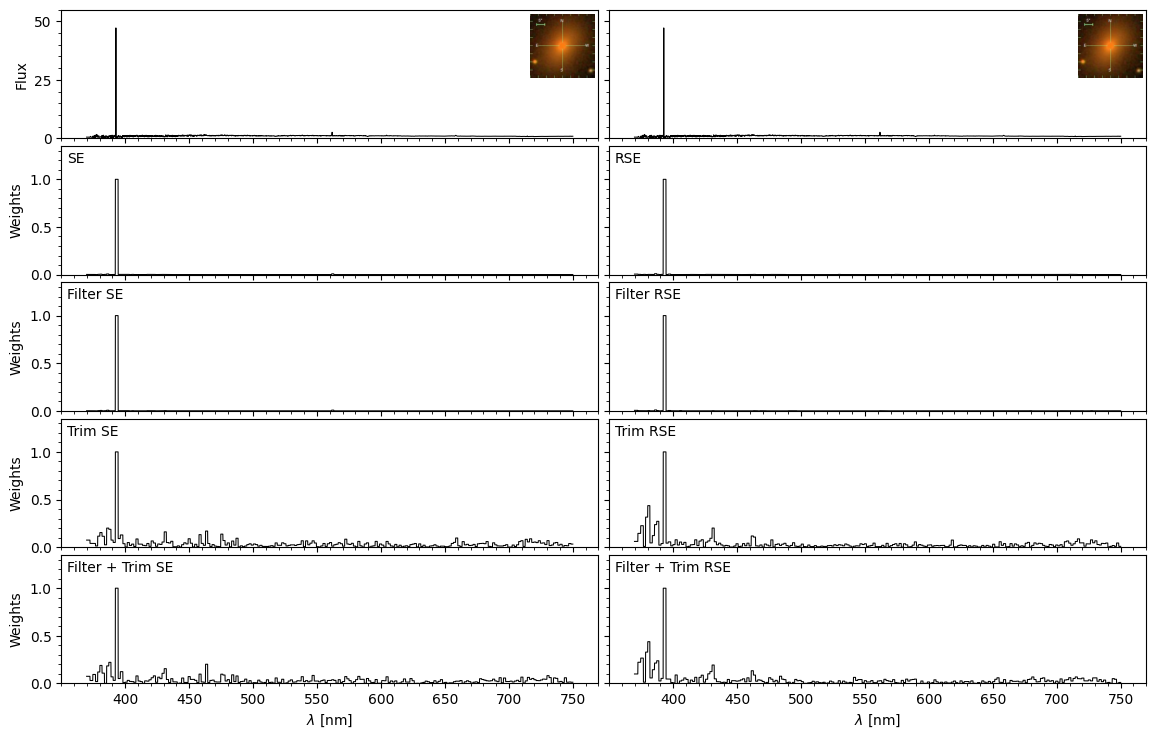

In [28]:
anomaly_name = "spike"

data = xai_common_dict[anomaly_name]
spectrum = data["spectrum"]
image = img_common_dict[anomaly_name]

spec_ylim = (0, 55)
spec_yticks = range(0, 51, 25)

# configuration for explanations
base_exp_config = {
    "indicator_starts": 0.06,
    "indicator_height": 0.07,
    "delta": 1,
    "fontsize": 6.5,
}

# lines to the spectrum and to each score
line_configs = {
    "spectrum": {
        "indicator_starts": 0.4,
        "indicator_height": 0.4,
        "delta": 1,
        "fontsize": 6.5,
        "active_lines": [],
    },
    # line indicators for scores
    "SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim SE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim SE": {**base_exp_config, "active_lines": []},
    "RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
    "Filter + Trim RSE": {
        **base_exp_config,
        "active_lines": [],
    },
}
fig, axs = plot_same_anomaly_explanations(
    data=data,
    wave_nm=wave_nm,
    line_configs=line_configs,
    spec_ylim=spec_ylim,
    spec_yticks=spec_yticks,
)

plt.subplots_adjust(hspace=0.06, wspace=0.02)